In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2



**Dataset utilizado**
- El dataset elegido para este proyecto es 'Formula 1 World Championship (1950 - 2024)' el cual consiste de información de carreras, pilotos, escuderias, qualis, cicuitos, tiempos de vuelta, etc. de los campeonatos desde 1950 hasta 2024.

In [212]:
PATH = "/content/drive/MyDrive/F1Dataset/Data/Raw"

results = pd.read_csv(f"{PATH}/results.csv")
races = pd.read_csv(f"{PATH}/races.csv")
drivers = pd.read_csv(f"{PATH}/drivers.csv")
constructors = pd.read_csv(f"{PATH}/constructors.csv")
circuits = pd.read_csv(f"{PATH}/circuits.csv")
qualifying = pd.read_csv(f"{PATH}/qualifying.csv")
driver_standings = pd.read_csv(f"{PATH}/driver_standings.csv")
constructor_standings = pd.read_csv(f"{PATH}/constructor_standings.csv")
status_df = pd.read_csv(f"{PATH}/status.csv")

In [214]:
results_data = results[
    [
        "raceId",
        "driverId",
        "constructorId",
        "grid",
        "positionOrder",
        "statusId",
        "laps"
    ]
]

races_data = races[
    [
        "raceId",
        "year",
        "round",
        "circuitId",
        "date"
    ]
]
races_data["date"] = pd.to_datetime(races_data["date"])

drivers_data = drivers[
    [
        "driverId",
        "driverRef",
        "dob"
    ]
]
drivers_data["dob"] = pd.to_datetime(drivers_data["dob"])

constructors_data = constructors[
    [
        "constructorId",
        "constructorRef"
    ]
]

circuits_data = circuits[
    [
        "circuitId",
        "circuitRef",
        "country",
        "alt"
    ]
]

qualifying_data = qualifying[
    [
        "raceId",
        "driverId",
        "constructorId",
        "position"
    ]
]

qualifying_data = qualifying_data.rename(
    columns={"position": "qualifying_position"}
)

/tmp/ipykernel_21150/3170095323.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  races_data["date"] = pd.to_datetime(races_data["date"])
/tmp/ipykernel_21150/3170095323.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers_data["dob"] = pd.to_datetime(drivers_data["dob"])


In [215]:
# Merge datasets utilizando las llaves primarias
df = results_data.merge(races_data, on="raceId", how="left")
df = df.merge(drivers_data, on="driverId", how="left")
df = df.merge(constructors_data, on="constructorId", how="left")
df = df.merge(circuits_data, on="circuitId", how="left")

df = df.merge(
    qualifying_data,
    on=["raceId", "driverId", "constructorId"],
    how="left"
)

df.head()

,raceId,driverId,constructorId,grid,positionOrder,statusId,laps,year,round,circuitId,date,driverRef,dob,constructorRef,circuitRef,country,alt,qualifying_position
0,18,1,1,1,1,1,58,2008,1,1,2008-03-16,hamilton,1985-01-07,mclaren,albert_park,Australia,10,1.0
1,18,2,2,5,2,1,58,2008,1,1,2008-03-16,heidfeld,1977-05-10,bmw_sauber,albert_park,Australia,10,5.0
2,18,3,3,7,3,1,58,2008,1,1,2008-03-16,rosberg,1985-06-27,williams,albert_park,Australia,10,7.0
3,18,4,4,11,4,1,58,2008,1,1,2008-03-16,alonso,1981-07-29,renault,albert_park,Australia,10,12.0
4,18,5,1,3,5,1,58,2008,1,1,2008-03-16,kovalainen,1981-10-19,mclaren,albert_park,Australia,10,3.0


## Features creados
los siguientes features fueron creados para que el modelo pudiera aprender más patrónes basados en datos históricos y algunas variables que podían ser calculadas a partir del dataset

In [216]:
df = df.sort_values(["driverId", "date"])

df["driver_age"] = (df["date"] - df["dob"]).dt.days // 365

df["driver_experience"] = df.groupby("driverId").cumcount()
df["constructor_experience"] = df.groupby("constructorId").cumcount()
df["driver_constructor_exp"] = df.groupby(["driverId","constructorId"]).cumcount()

df["is_win"] = (df["positionOrder"] == 1).astype(int)
df["driver_wins"]      = df.groupby("driverId")["is_win"].cumsum() - df["is_win"]
df["constructor_wins"] = df.groupby("constructorId")["is_win"].cumsum() - df["is_win"]

df["finished"] = (df["statusId"] == 1).astype(int)
df["dnf_score"] = (
    df.groupby("constructorId")["finished"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df["prev_position"] = df.groupby("driverId")["positionOrder"].shift(1)

df["driver_avg_finish"]      = df.groupby("driverId")["positionOrder"]\
    .transform(lambda x: x.shift(1).expanding().mean())
df["constructor_avg_finish"] = df.groupby("constructorId")["positionOrder"]\
    .transform(lambda x: x.shift(1).expanding().mean())

df = df.sort_values(["driverId","circuitId","date"]).reset_index(drop=True)
df["driver_circuit_avg_finish"] = df.groupby(["driverId","circuitId"])["positionOrder"]\
    .transform(lambda x: x.shift(1).expanding().mean())

df["driver_avg_last_5"] = (
    df.groupby("driverId")["positionOrder"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["constructor_avg_last_5"] = (
    df.groupby("constructorId")["positionOrder"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["driver_avg_last_3"] = (
    df.groupby("driverId")["positionOrder"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df["constructor_avg_last_3"] = (
    df.groupby("constructorId")["positionOrder"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df["driver_avg_grid"] = (
    df.groupby("driverId")["grid"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

df["driver_form_delta"] = df["driver_avg_last_3"] - df["driver_avg_last_5"]
df["constructor_form_delta"] = df["constructor_avg_last_3"] - df["constructor_avg_last_5"]

df["grid_vs_qualifying"] = df["grid"] - df["qualifying_position"]
df["driver_grid_avg_diff"] = df["grid"] - df["driver_avg_grid"]

df["is_pole"] = (df["grid"] == 1).astype(int)
df["starts_top_3"] = (df["grid"] <= 3).astype(int)
df["starts_top_10"] = (df["grid"] <= 10).astype(int)

In [217]:
ds = driver_standings[["raceId","driverId","points","position","wins"]]
ds = ds.merge(races[["raceId","year","round"]], on="raceId", how="left")
ds = ds.sort_values(["driverId","year","round"])

for col, new_col in [("points","driver_pts_before"), ("position","driver_pos_before"), ("wins","driver_wins_standing")]:
    ds[new_col] = ds.groupby("driverId")[col].shift(1)

df = df.merge(ds[["raceId","driverId","driver_pts_before","driver_pos_before","driver_wins_standing"]],
              on=["raceId","driverId"], how="left")

cs = constructor_standings[["raceId","constructorId","points","position"]]
cs = cs.merge(races[["raceId","year","round"]], on="raceId", how="left")
cs = cs.sort_values(["constructorId","year","round"])

for col, new_col in [("points","const_pts_before"), ("position","const_pos_before")]:
    cs[new_col] = cs.groupby("constructorId")[col].shift(1)

df = df.merge(cs[["raceId","constructorId","const_pts_before","const_pos_before"]],
              on=["raceId","constructorId"], how="left")

In [10]:
print(df.isnull().sum())

raceId                           0
driverId                         0
constructorId                    0
grid                             0
positionOrder                    0
statusId                         0
laps                             0
year                             0
round                            0
circuitId                        0
date                             0
driverRef                        0
dob                              0
constructorRef                   0
circuitRef                       0
country                          0
alt                              0
qualifying_position          16275
driver_age                       0
driver_experience                0
constructor_experience           0
driver_constructor_exp           0
is_win                           0
driver_wins                      0
constructor_wins                 0
finished                         0
dnf_score                      211
prev_position                  861
driver_avg_finish   

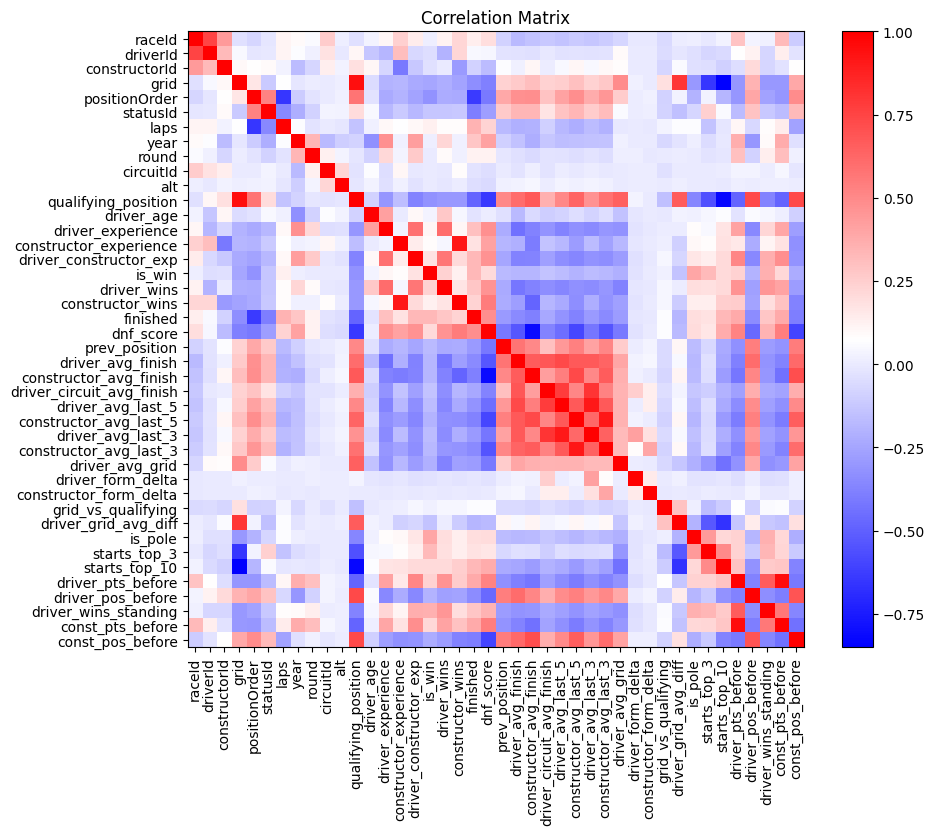

In [169]:
corr_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='bwr', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

## Filtro temporal

Se decidió utilizar datos desde el año 2010 hasta 2024 para reducir variaciones históricas en reglas, sistemas de puntuación y cambios técnicos de la Fórmula 1. Esta decisión también se alinea con el paper base, el cual trabaja con datos recientes para mantener mayor consistencia en el análisis.

In [218]:
# discard non-qualified, started from pit, disqualified drivers
df = df[df["grid"] > 0]

# use data since 2010
df = df[df["year"] >= 2010]

# limit position order between 1-20
df = df[df["positionOrder"].between(1,20)]

print("\nMerged dataset shape:", df.shape)
print(f"Dataset: {len(df):,} registros")
print(f"   Años: {df['year'].min()}-{df['year'].max()}")

df["qualifying_position"] = df["qualifying_position"].fillna(df["grid"])

df = df.dropna()

df["qualifying_position"] = df["qualifying_position"].fillna(df["grid"])

print("\nMerged dataset shape:", df.shape)
print(f"Dataset: {len(df):,} registros")
print(f"   Años: {df['year'].min()}-{df['year'].max()}")


Merged dataset shape: (6015, 48)
Dataset: 6,015 registros
   Años: 2010-2024

Merged dataset shape: (4714, 48)
Dataset: 4,714 registros
   Años: 2010-2024


## Variable objetivo

La variable objetivo del proyecto es `positionOrder`, la cual representa la posición final obtenida por un piloto en una carrera.

El problema se plantea como una tarea de regresión, ya que se busca predecir un valor numérico correspondiente a la posición final.

In [219]:
target_column = "positionOrder"

features = [
    "round",
    "grid",
    "qualifying_position",
    "laps",
    "driver_age",
    "driver_experience",
    "constructor_experience",
    "driver_constructor_exp",
    "driver_wins",
    "constructor_wins",
    "dnf_score",
    "prev_position",
    "driver_avg_finish",
    "constructor_avg_finish",
    "driver_circuit_avg_finish",
    "driver_pts_before",
    "driver_pos_before",
    "driver_wins_standing",
    "const_pts_before",
    "const_pos_before",
    "circuitId",
    "country",
    "alt",
    "grid_vs_qualifying",
    "driver_grid_avg_diff",
    "is_pole",
    "starts_top_3",
    "starts_top_10",
    "driver_form_delta",
    "constructor_form_delta",
    "driver_avg_last_5",
    "constructor_avg_last_5",

    "circuitRef",
    "constructorRef"
]


X = df[features]
y = df[target_column]

In [221]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [222]:
# normalizar columnas categóricas
categorical_columns = [
    "constructorRef",
    "circuitRef",
    "country"
]

X_train_encoded = pd.get_dummies(X_train_original, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_original, columns=categorical_columns)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [223]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [224]:
train_data = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
train_data[target_column] = y_train.reset_index(drop=True)

test_data = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)
test_data[target_column] = y_test.reset_index(drop=True)

In [225]:
X_train_final = train_data.drop(target_column, axis=1)
y_train_final = train_data[target_column]

X_test_final = test_data.drop(target_column, axis=1)
y_test_final = test_data[target_column]

'''
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_final.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
'''

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_final.shape[1], kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)


history = model.fit(
    X_train_final,
    y_train_final,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 28.0453 - mae: 3.9158 - val_loss: 15.1090 - val_mae: 2.8528 - learning_rate: 0.0010
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.2555 - mae: 2.9754 - val_loss: 12.2831 - val_mae: 2.6536 - learning_rate: 0.0010
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.7495 - mae: 2.8260 - val_loss: 12.0131 - val_mae: 2.5744 - learning_rate: 0.0010
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.8799 - mae: 2.7181 - val_loss: 13.4629 - val_mae: 2.7041 - learning_rate: 0.0010
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.4769 - mae: 2.6627 - val_loss: 12.5210 - val_mae: 2.5636 - learning_rate: 0.0010
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.9457 - mae: 2.6225 - val_loss: 11.9103 - val_mae: 2.5194 - learning_rate: 0.0010
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.4841 - mae: 2.5518 - val_loss: 11.8602 - val_mae: 2.5415 - learning_rate: 0.00

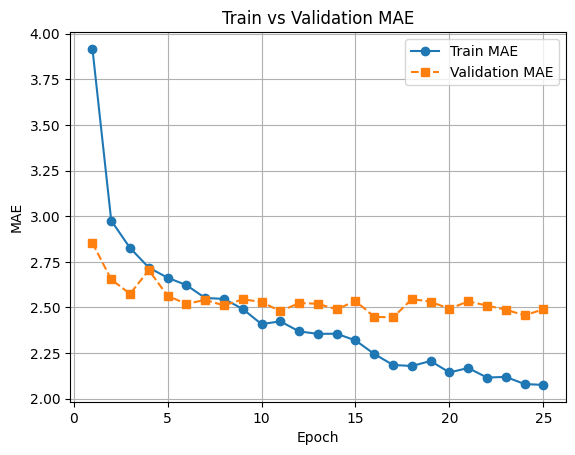

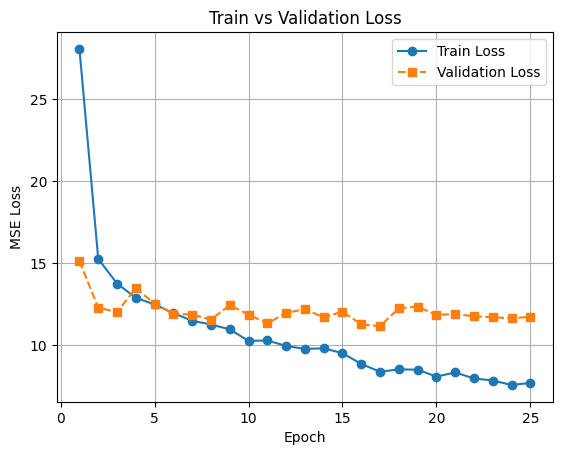

In [226]:
mae_train = history.history["mae"]
loss_train = history.history["loss"]
mae_val = history.history["val_mae"]
loss_val = history.history["val_loss"]

epochs = range(1, len(mae_train) + 1)

plt.figure()
plt.plot(epochs, mae_train, "o-", label="Train MAE")
plt.plot(epochs, mae_val, "s--", label="Validation MAE")
plt.title("Train vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, loss_train, "o-", label="Train Loss")
plt.plot(epochs, loss_val, "s--", label="Validation Loss")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [227]:
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train_final, y_train_final)

gbr_pred = gbr.predict(X_test_final)

In [228]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [229]:
nn_pred = model.predict(X_test_final).flatten()

nn_results = evaluate_model(
    y_test_final,
    nn_pred,
    "Improved Neural Network"
)

gbr_results = evaluate_model(
    y_test_final,
    gbr_pred,
    "Gradient Boosting Regressor"
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Improved Neural Network
MAE: 2.5648880004882812
RMSE: 3.481974506151189
R²: 0.6226040124893188
Gradient Boosting Regressor
MAE: 2.291079203805509
RMSE: 3.158525748568136
R²: 0.689461883077161


In [230]:
results_df = pd.DataFrame([nn_results, gbr_results])
results_df

,Model,MAE,RMSE,R2
0,Improved Neural Network,2.564888,3.481975,0.622604
1,Gradient Boosting Regressor,2.291079,3.158526,0.689462


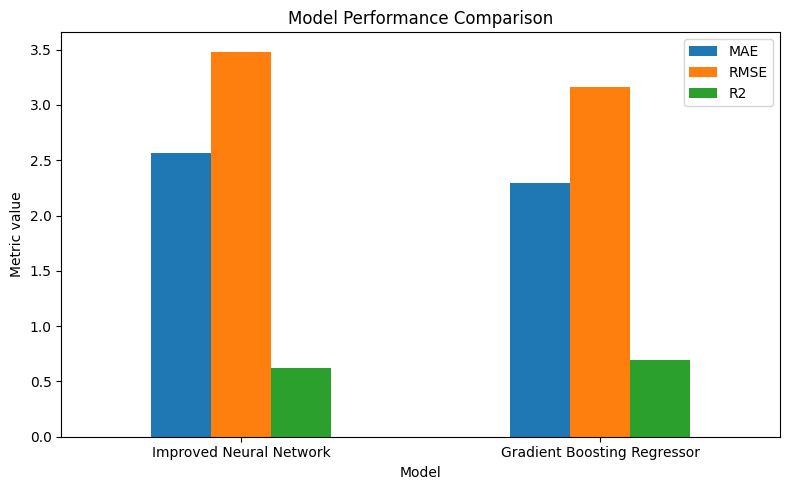

In [231]:
results_df.plot(x="Model", y=["MAE", "RMSE", "R2"], kind="bar", figsize=(8, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

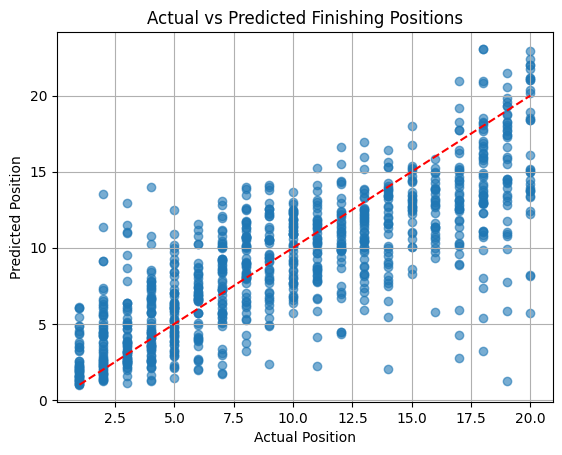

In [232]:
plt.figure()
plt.scatter(y_test, nn_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red"
)
plt.title("Actual vs Predicted Finishing Positions")
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")
plt.grid(True)
plt.show()

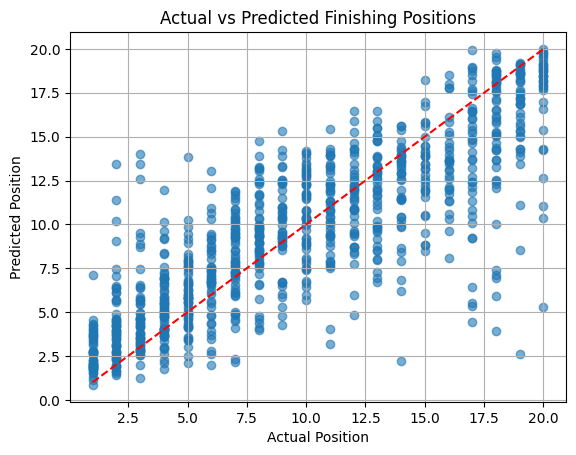

In [233]:
# gbr results graphs

plt.figure()
plt.scatter(y_test_final, gbr_pred, alpha=0.6)
plt.plot(
    [y_test_final.min(), y_test_final.max()],
    [y_test_final.min(), y_test_final.max()],
    linestyle="--",
    color="red"
)
plt.title("Actual vs Predicted Finishing Positions")
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")
plt.grid(True)
plt.show()

In [ ]:
import joblib
import os

MODEL_PATH = "/content/drive/MyDrive/F1Dataset/models"

model.save(f"{MODEL_PATH}/model.keras")

joblib.dump(scaler, f"{MODEL_PATH}/scaler.pkl")
joblib.dump(X_train_encoded.columns.tolist(), f"{MODEL_PATH}/model_columns.pkl")

test_original = X_test_original.copy()
test_original[target_column] = y_test.values

test_original.to_csv(f"{MODEL_PATH}/test_original.csv", index=False)

print("Modelo, scaler, columnas y test original guardados correctamente.")

Modelo, scaler, columnas y test original guardados correctamente.
